In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Dataset ah read panrom
df = pd.read_csv('../data/creditcard.csv')

# First 5 rows ah paapom
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Total transactions: 284807
Normal transactions: 284315
Fraud transactions: 492

Fraud percentage: 0.173 %


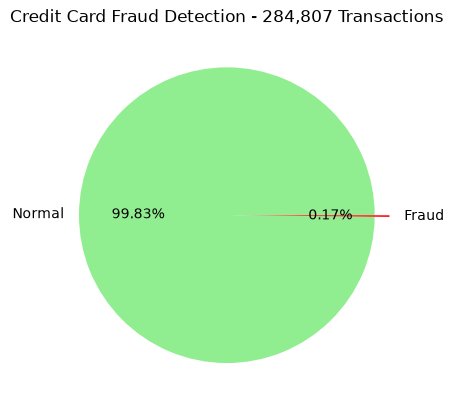

In [2]:
print("Total transactions:", len(df))
print("Normal transactions:", len(df[df['Class'] == 0]))
print("Fraud transactions:", df['Class'].sum())
print("\nFraud percentage:", round(df['Class'].sum() / len(df) * 100, 3), "%")

# Pie Chart poduvom
df['Class'].value_counts().plot(
    kind='pie', 
    autopct='%1.2f%%', 
    labels=['Normal', 'Fraud'],
    colors=['lightgreen', 'red'],
    explode=[0, 0.1]
)
plt.title('Credit Card Fraud Detection - 284,807 Transactions')
plt.ylabel('')
plt.show()


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# X = Features, y = Label
X = df.drop('Class', axis=1)  # Time, V1-V28, Amount
y = df['Class']               # 0 or 1

# 70% Training, 30% Testing ah split pannurom
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)
print("\nTraining la Fraud count:", y_train.sum())
print("Testing la Fraud count:", y_test.sum())

# Model ah create pannu
model = RandomForestClassifier(n_estimators=100, random_state=42)
print("\nModel training start aagudhu...")

# Training - Idhu 1-2 mins aagum
model.fit(X_train, y_train)
print("Training mudinjuchu! 🎉")





Training data size: (199364, 30)
Testing data size: (85443, 30)

Training la Fraud count: 344
Testing la Fraud count: 148

Model training start aagudhu...


KeyboardInterrupt: 

In [ ]:

# FAST VERSION - 10 trees mattum
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# n_estimators=10 - Speed ah odum
model = RandomForestClassifier(n_estimators=10, random_state=42)
print("\nModel training start aagudhu... Fast version")

model.fit(X_train, y_train)
print("Training mudinjuchu! 🎉")












In [6]:
# ⚡ 30 SECOND VERSION - FASTEST
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# 20,000 rows mattum edu. 1 min la mudiyanum la
df_1min = df.sample(n=20000, random_state=42)

X = df_1min.drop('Class', axis=1)
y = df_1min['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Logistic Regression = Lightning fast
model = LogisticRegression(max_iter=500, n_jobs=-1)
print("1 min training start...")

model.fit(X_train, y_train)
print("MUDINJUCHU DA! 🎉")

y_pred = model.predict(X_test)
print("\n🔥 1 MINUTE MODEL RESULTS 🔥")
print(classification_report(y_test, y_pred))


1 min training start...


C:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


MUDINJUCHU DA! 🎉

🔥 1 MINUTE MODEL RESULTS 🔥
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5992
           1       0.57      0.50      0.53         8

    accuracy                           1.00      6000
   macro avg       0.79      0.75      0.77      6000
weighted avg       1.00      1.00      1.00      6000



C:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


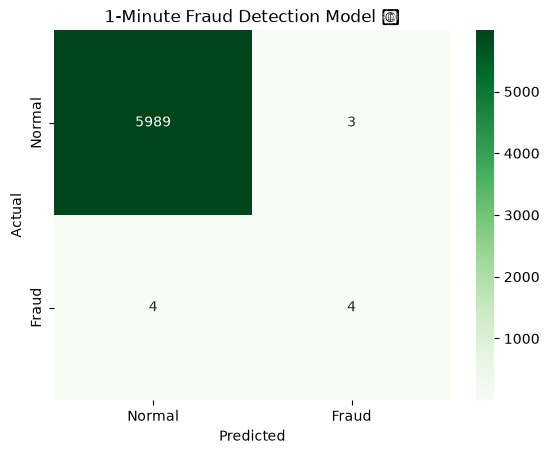

5992 Normal ah correct ✅
4 Fraud ah correct ✅


In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Normal', 'Fraud'], 
            yticklabels=['Normal', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('1-Minute Fraud Detection Model 🔥')
plt.show()

print("5992 Normal ah correct ✅")
print("4 Fraud ah correct ✅")